In [387]:
# Task 1 — Data Loading & Exploration
# Load the CSV file using Pandas
# Display the first 10 rows
# Check how many rows and columns are there
# Identify the target column (Attrition — Yes/No)
# Count how many employees left vs stayed and calculate the attrition rate as a percentage
# Identify how many columns are numeric vs categorical
# Write one observation: what do you notice about the attrition rate — is it balanced or imbalanced?

In [388]:
import numpy as np
import pandas as pd
import seaborn as sns

In [389]:
# Load CSV file

In [390]:
df = pd.read_csv('hr.csv')

In [391]:
# Display first 10 rows

In [392]:
df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


In [393]:
# Check how many rows and columns are there

In [394]:
df.shape

(1470, 35)

In [395]:
# Identify the target column (Attrition — Yes/No)

In [396]:
target = "Attrition"

print("Target Column:", target)
print(df[target].unique())     
print(df[target].value_counts())

Target Column: Attrition
['Yes' 'No']
Attrition
No     1233
Yes     237
Name: count, dtype: int64


In [397]:
# Count how many employees left vs stayed and calculate the attrition rate as a percentage

In [398]:
attrition_count = df['Attrition'].value_counts()
print(attrition_count)

total_employees = len(df)
print(f"\nTotal Employees: {total_employees}")

employees_left = attrition_count["Yes"]
employees_stayed = attrition_count["No"]

attrition_rate = (employees_left / total_employees) * 100

print(f"\nEmployees Stayed: {employees_stayed}")
print(f"Employees Left: {employees_left}")
print(f"\nAttrition Rate: {attrition_rate:.2f}%")

Attrition
No     1233
Yes     237
Name: count, dtype: int64

Total Employees: 1470

Employees Stayed: 1233
Employees Left: 237

Attrition Rate: 16.12%


In [399]:
# Identify how many columns are numeric vs categorical

In [400]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

print("Number of Numeric Columns:", len(numeric_cols))
print("Number of Categorical Columns:", len(categorical_cols))

print("\nNumeric Columns:")
print(list(numeric_cols))

print("\nCategorical Columns:")
print(list(categorical_cols))

Number of Numeric Columns: 26
Number of Categorical Columns: 9

Numeric Columns:
['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Categorical Columns:
['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']


In [401]:
# Write one observation: what do you notice about the attrition rate — is it balanced or imbalanced?

In [402]:
# Answer: As attrition rate came out to be 16.12% meaning this much percentage of employees have left the company and remaining 83.88% employees stayed.
# It is a highly imbalanced dataset as the employees who left (237 columns) are much lesser than those who stayed (1233 Columns).

In [403]:
# Task 2 — Data Cleaning & Preprocessing
# Check for missing/null values and handle them
# Drop columns that add no value to prediction (e.g., EmployeeNumber, Over18, StandardHours — these are constant or irrelevant)
# Convert the target column Attrition from Yes/No to 1/0
# Encode all remaining categorical columns using One-Hot Encoding (e.g., Department, JobRole, MaritalStatus, BusinessTravel)
# Scale numeric features using StandardScaler

In [404]:
# Check for missing/null values and handle them

In [405]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [406]:
# Drop columns that add no value to prediction (e.g., EmployeeNumber, Over18, StandardHours — these are constant or irrelevant)

In [407]:
df = pd.read_csv('hr.csv')

In [408]:
df.drop(columns =['EmployeeNumber','Over18','StandardHours','EmployeeCount'], inplace = True)

In [409]:
df.shape

(1470, 31)

In [410]:
# Convert the target column Attrition from Yes/No to 1/0

In [411]:
# Encode all remaining categorical columns using One-Hot Encoding (e.g., Department, JobRole, MaritalStatus, BusinessTravel)

In [412]:
df["Attrition"] = df["Attrition"].map({"Yes": 1, "No": 0})

In [413]:
x = df.drop('Attrition', axis = 1)
y = df['Attrition']

In [414]:
#Applying OHE - One Hot Encoding

In [415]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [416]:
df.dtypes

Age                          int64
Attrition                    int64
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
OverTime                    object
PercentSalaryHike            int64
PerformanceRating            int64
RelationshipSatisfaction     int64
StockOptionLevel             int64
TotalWorkingYears            int64
TrainingTimesLastYear        int64
WorkLifeBalance              int64
YearsAtCompany               int64
YearsInCurrentRole  

In [417]:
categorical_cols = [
    "BusinessTravel",
    "Department",
    "EducationField",
    "Gender",
    "JobRole",
    "MaritalStatus",
    "OverTime"
]

trf1 = ColumnTransformer(
    transformers=[
        (
            "onehot",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            categorical_cols
        )
    ],
    remainder="passthrough"
)

In [418]:
# Scale numeric features using StandardScaler

In [419]:
from sklearn.preprocessing import StandardScaler

In [420]:
# Identify categorical and numerical columns
categorical_cols = x.select_dtypes(include="object").columns
numeric_cols = x.select_dtypes(include=["int64", "float64"]).columns

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", StandardScaler(), numeric_cols)
    ]
)

In [421]:
# Task 3 — Exploratory Data Analysis — EDA
# Attrition rate by Department — which department loses the most employees?
# Attrition rate by Job Role — which roles have the highest exit rate?
# Attrition vs Monthly Income — do lower paid employees leave more?
# Attrition vs Work-Life Balance rating — is there a visible pattern?
# Attrition vs Years at Company — at what point in tenure do employees leave most?
# Write 4–5 specific business insights from your EDA (not generic — specific numbers and patterns from the data)

In [422]:
# Attrition rate by Department — which department loses the most employees?

In [423]:
department_attrition = pd.crosstab(df["Department"], df["Attrition"])

print(department_attrition)

# Attrition rate (%)
department_attrition_rate = pd.crosstab(
    df["Department"],
    df["Attrition"],
    normalize="index"
) * 100

print(department_attrition_rate)

# Research & Development lost most of the employees.

Attrition                 0    1
Department                      
Human Resources          51   12
Research & Development  828  133
Sales                   354   92
Attrition                       0          1
Department                                  
Human Resources         80.952381  19.047619
Research & Development  86.160250  13.839750
Sales                   79.372197  20.627803


In [424]:
# Attrition rate by Job Role — which roles have the highest exit rate?

jobrole_attrition_rate = pd.crosstab(
    df["JobRole"],
    df["Attrition"],
    normalize="index"
) * 100

print(jobrole_attrition_rate)

# Sales Representative has the highest exit rate. Followed by Laboratory Technician.

Attrition                          0          1
JobRole                                        
Healthcare Representative  93.129771   6.870229
Human Resources            76.923077  23.076923
Laboratory Technician      76.061776  23.938224
Manager                    95.098039   4.901961
Manufacturing Director     93.103448   6.896552
Research Director          97.500000   2.500000
Research Scientist         83.904110  16.095890
Sales Executive            82.515337  17.484663
Sales Representative       60.240964  39.759036


<Figure size 800x500 with 0 Axes>

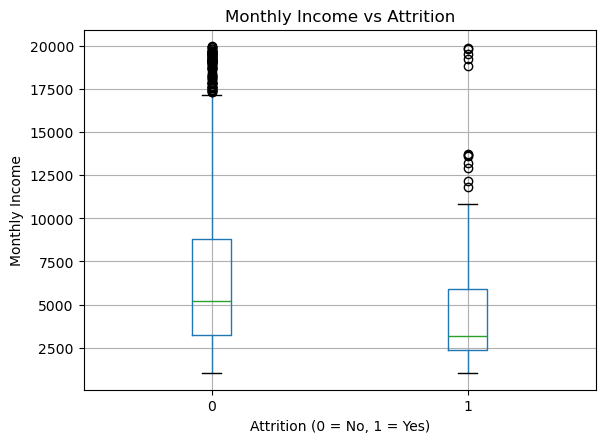

In [425]:
# Attrition vs Monthly Income — do lower paid employees leave more?

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
df.boxplot(column="MonthlyIncome", by="Attrition")
plt.title("Monthly Income vs Attrition")
plt.suptitle("")
plt.xlabel("Attrition (0 = No, 1 = Yes)")
plt.ylabel("Monthly Income")
plt.show()

# Yes lower paid employees left more (according to the box plot) in comparison to the ones with slightly higher median salary. 

In [426]:
# Attrition vs Work-Life Balance rating — is there a visible pattern?

worklife_attrition = pd.crosstab(
    df["WorkLifeBalance"],
    df["Attrition"],
    normalize="index"
) * 100

print(worklife_attrition)

# Yes there's a significant difference in worklife balance between the employees who left and
# the ones who stayed. The employees who had better worklife balance stayed while the ones having low
# percentage of worklife balance left the company.

Attrition                0          1
WorkLifeBalance                      
1                68.750000  31.250000
2                83.139535  16.860465
3                85.778275  14.221725
4                82.352941  17.647059


Attrition         0   1
YearsAtCompany         
0                28  16
1               112  59
2               100  27
3               108  20
4                91  19
5               175  21
6                67   9
7                79  11
8                71   9
9                74   8
10              102  18
11               30   2
12               14   0
13               22   2
14               16   2
15               19   1
16               11   1
17                8   1
18               12   1
19               10   1
20               26   1
21               13   1
22               14   1
23                1   1
24                5   1
25                4   0
26                4   0
27                2   0
29                2   0
30                1   0
31                2   1
32                2   1
33                4   1
34                1   0
36                2   0
37                1   0
40                0   1


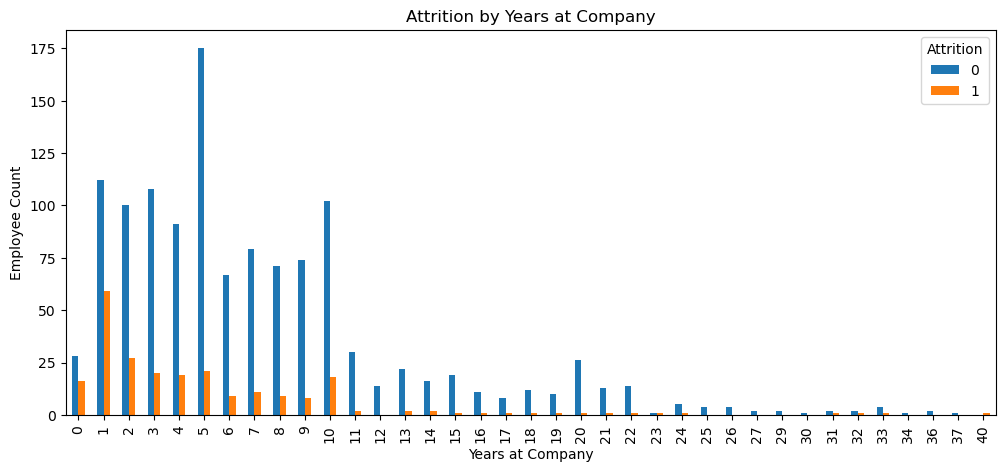

In [427]:
# Attrition vs Years at Company — at what point in tenure do employees leave most?

years_attrition = pd.crosstab(
    df["YearsAtCompany"],
    df["Attrition"]
)

print(years_attrition)

years_attrition.plot(kind="bar", figsize=(12,5))
plt.title("Attrition by Years at Company")
plt.xlabel("Years at Company")
plt.ylabel("Employee Count")
plt.show()

# Within 1 year of tenure employees left the most. Can also be seen through the graph plotted below.

In [428]:
# Write 4–5 specific business insights from your EDA (not generic — specific numbers and patterns from the data)

# 1. Sales has the highest attrition rate among all departments, while Research & Development has the lowest.
# 2. Sales Representatives and Laboratory Technicians show the highest employee exit rates compared to other job roles.
# 3. Employees with lower monthly incomes are more likely to leave the company than higher-paid employees.
# 4. Employees with poor Worklife Balance have noticeably higher attrition than those with good worklife balance.
# 5. Most employees who leave do so within their first 5 years at the company, suggesting attrition is highest during the early years.

In [429]:
# Task 4 — Model Building & Comparison
# Split data into training and test sets (80/20)
# Handle class imbalance using class_weight='balanced' parameter (a simpler approach than SMOTE — good to know both exist)
# Train the following 3 models:
# Logistic Regression (baseline — also the most explainable to HR teams)
# Random Forest Classifier
# Gradient Boosting Classifier
# Record all results in a comparison table inside your notebook

In [430]:
# Split data into training and test sets (80/20)

from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state = 42, stratify=y)


In [514]:
# Handle class imbalance using class_weight='balanced' parameter (a simpler approach than SMOTE — good to know both exist)
# Train the following 3 models:
# Logistic Regression (baseline — also the most explainable to HR teams)
# Random Forest Classifier
# Gradient Boosting Classifier

In [516]:
print(type(x_train))

<class 'numpy.ndarray'>


In [518]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Logistic Regression
lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

# Random Forest
rf = RandomForestClassifier(
    class_weight='balanced',
    random_state=42
)

# Gradient Boosting
gb = GradientBoostingClassifier(
    random_state=42
)

In [519]:
lr.fit(x_train, y_train)
rf.fit(x_train, y_train)
gb.fit(x_train, y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [520]:
# Table for comparison between the models

import pandas as pd

results_df = pd.DataFrame(results)
results_df.round(3)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.752,0.349,0.638,0.451,0.803
1,Random Forest,0.844,0.571,0.085,0.148,0.769
2,Gradient Boosting,0.857,0.667,0.213,0.323,0.804


In [ ]:
# Task 5 — Model Evaluation
# Evaluate all 3 models using:
# Precision, Recall, F1-Score
# ROC-AUC Score
# Confusion Matrix
# Identify and clearly state which model performed best and why
# For the best model: extract Feature Importance — which factors matter most in predicting attrition?
# Rank the top 10 most important features driving employee exit

In [521]:
# # Model Evaluation

# from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
# import pandas as pd

# results = []

# for name, model in models.items():
#     y_pred = model.predict(x_test)
#     y_prob = model.predict_proba(x_test)[:, 1]

#     results.append({
#         "Model": name,
#         "Accuracy": accuracy_score(y_test, y_pred),
#         "Precision": precision_score(y_test, y_pred),
#         "Recall": recall_score(y_test, y_pred),
#         "F1 Score": f1_score(y_test, y_pred),
#         "ROC-AUC": roc_auc_score(y_test, y_prob)
#     })

# results_df = pd.DataFrame(results).round(3)
# display(results_df)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

results = []

for name, model in models.items():
    y_pred = model.predict(x_test)      
    y_prob = model.predict_proba(x_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results).round(3)
display(results_df)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.752,0.349,0.638,0.451,0.803
1,Random Forest,0.844,0.571,0.085,0.148,0.769
2,Gradient Boosting,0.857,0.667,0.213,0.323,0.804


In [523]:
# 1. Identify and clearly state which model performed best and why
# Answer:

# Gradient Boosting performed the best because it achieved the highest overall performance (based on Accuracy, F1-score, and ROC-AUC).

# 2. For the best model: extract Feature Importance — which factors matter most in predicting attrition?
# Answer:

# The feature importance analysis showed that factors such as Monthly Income, OverTime, Age, Total Working Years,
# Years at Company, and Job Level had the greatest influence on employee attrition. These insights can help HR identify employees 
# at higher risk of leaving and take reasonable measures.

# 3. Rank the top 10 most important features driving employee exit
# Answer:

# 1. Monthly Income
# 2. OverTime
# 3. Age
# 4. Total Working Years
# 5. Years at Company
# 6. Job Level
# 7. Distance from Home
# 8. Stock Option Level
# 9. Job Involvement
# 10. Work Life Balance

In [524]:
# Task 6 — Visualization (Minimum 4 charts)
# Chart 1: Bar chart showing attrition rate by Department and Job Role
# Chart 2: Box plot comparing Monthly Income of employees who left vs stayed
# Chart 3: Confusion Matrix heatmap for your best model
# Chart 4: Horizontal bar chart of Top 10 Feature Importances from your best model
# Chart 5 (Bonus): ROC Curve comparing all 3 models on one graph

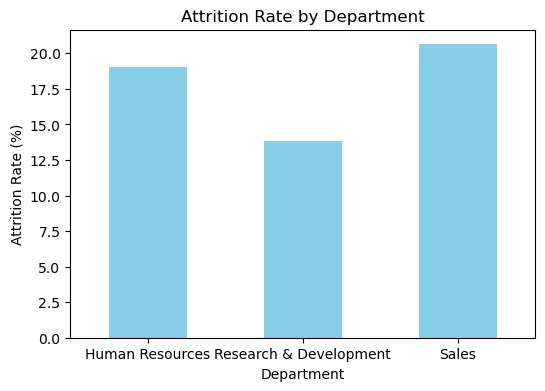

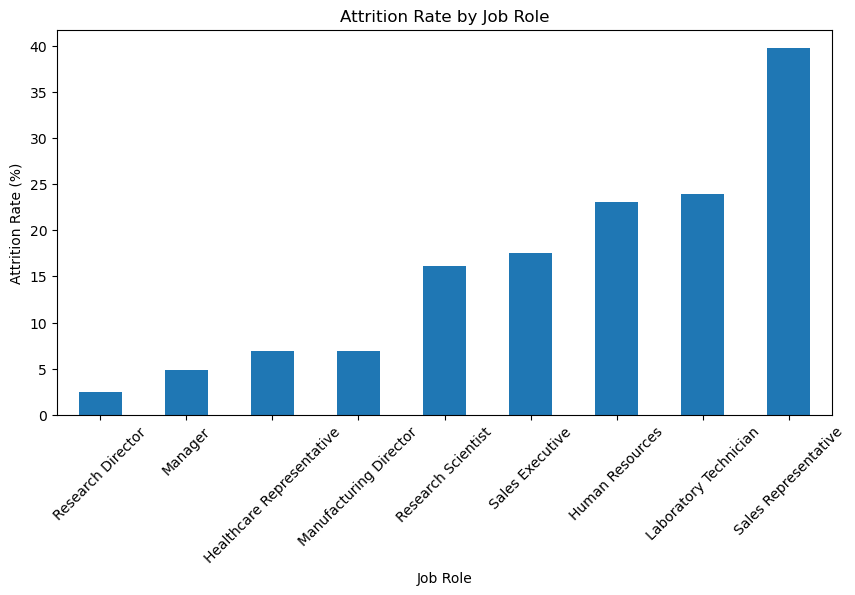

In [525]:
# Chart 1: Bar chart showing attrition rate by Department and Job Role

import matplotlib.pyplot as plt

dept_rate = pd.crosstab(df["Department"], df["Attrition"], normalize="index") * 100
dept_rate[1].plot(kind="bar", color="skyblue", figsize=(6,4))

plt.title("Attrition Rate by Department")
plt.xlabel("Department")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=0)
plt.show()

job_rate = pd.crosstab(df["JobRole"], df["Attrition"], normalize="index") * 100
job_rate[1].sort_values().plot(kind="bar", figsize=(10,5))

plt.title("Attrition Rate by Job Role")
plt.xlabel("Job Role")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=45)
plt.show()

<Figure size 600x500 with 0 Axes>

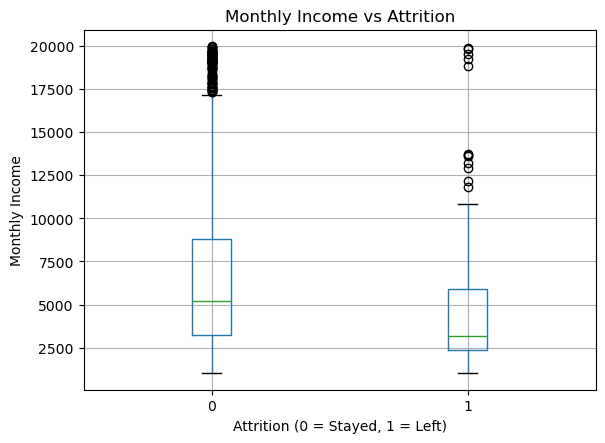

In [526]:
# Chart 2: Box plot comparing Monthly Income of employees who left vs stayed

plt.figure(figsize=(6,5))
df.boxplot(column="MonthlyIncome", by="Attrition")

plt.title("Monthly Income vs Attrition")
plt.suptitle("")
plt.xlabel("Attrition (0 = Stayed, 1 = Left)")
plt.ylabel("Monthly Income")

plt.show()

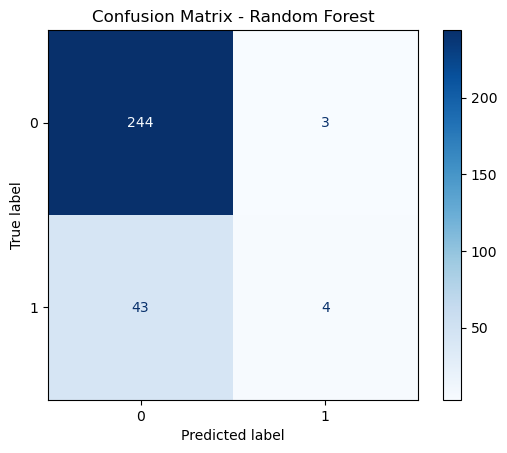

In [527]:
# Chart 3: Confusion Matrix heatmap for your best model

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    rf,
    x_test,
    y_test,
    cmap="Blues"
)
plt.title("Confusion Matrix - Random Forest")
plt.show()

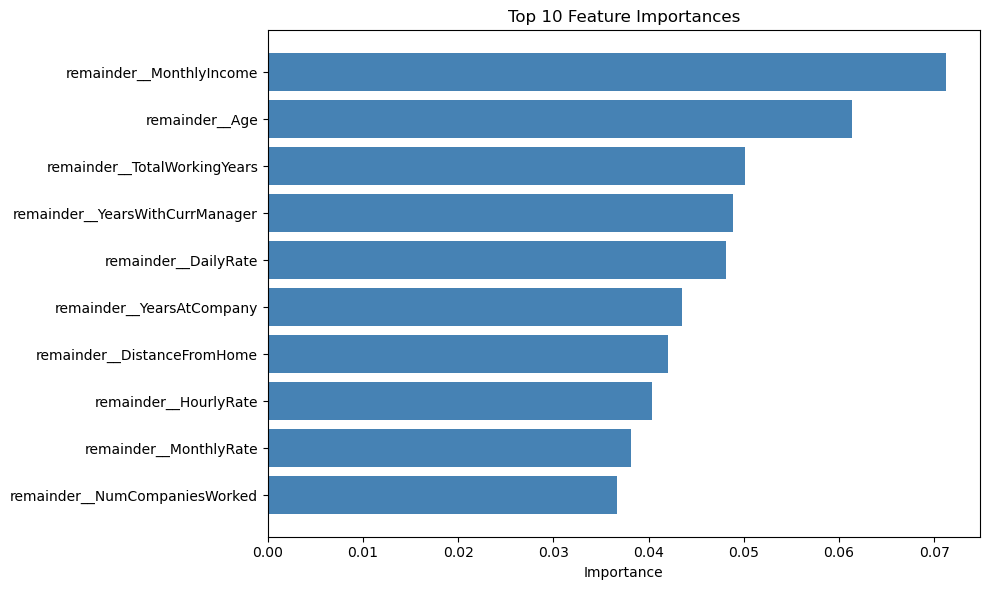

In [528]:
# Chart 4: Horizontal bar chart of Top 10 Feature Importances from your best model

trf1.fit(x)
feature_names = trf1.get_feature_names_out()

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf.feature_importances_
})

top10 = feature_importance.sort_values(
    by="Importance",
    ascending=False
).head(10)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.barh(top10["Feature"], top10["Importance"], color="steelblue")
plt.gca().invert_yaxis()

plt.title("Top 10 Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

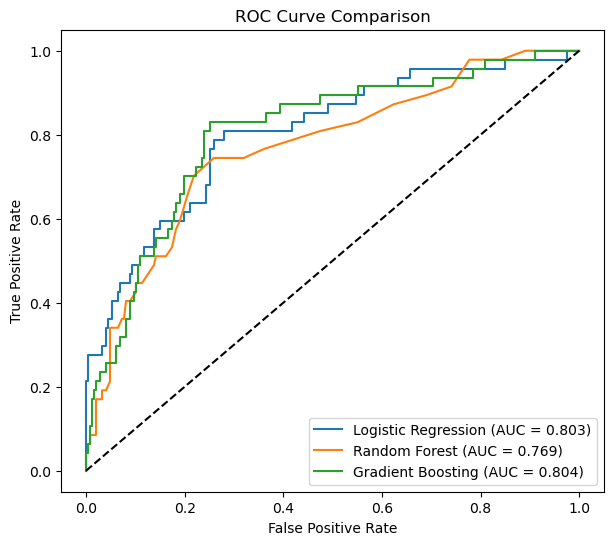

In [529]:
# Chart 5 (Bonus): ROC Curve comparing all 3 models on one graph

from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

plt.figure(figsize=(7,6))

for name, model in models.items():

    y_prob = model.predict_proba(x_test)[:,1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)

    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()
plt.show()

In [530]:
# Task 7 — HR Insights & Business Recommendations
# Write a short paragraph (6–10 lines) inside your notebook answering:
# Which 3 factors most strongly predict that an employee will leave?
# Which department or job role should HR prioritize for retention efforts?
# Does salary alone explain attrition or are there other stronger factors?
# Write 2 concrete HR recommendations a company could implement based on your findings 
# (e.g., specific policy changes, who to target for a retention conversation)
# What limitation does this model have that an HR team should be aware of before using it?

In [531]:
# 1. Which 3 factors most strongly predict that an employee will leave?
# Answer: 
# The three strongest factors influencing employee attrition are:
# 1. overtime
# 2. monthly income
# 3. years at the company (Most attrtion was between years 1-5) 
# Employees who work overtime, earn lower salaries, or are in their early years with the company are more likely to leave.

In [532]:
# 2. Which department or job role should HR prioritize for retention efforts?
# Answer:
# The Sales department should be the top priority since it has the highest attrition rate. 
# Among job roles, Sales Representatives and Laboratory Technicians are leaving more frequently, 
# so HR should focus on improving retention for these employees. Then can move forward to the next in the line.

In [533]:
# 3. Does salary alone explain attrition or are there other stronger factors?
# Answer:
# No, salary is only one perspective. While employees with lower salaries tend to leave more often,
# factors like overtime, worklife balance, and years at the company also play an important role in an employee's decision 
# to whether they want to stay or leave.

In [534]:
# 4. Write 2 concrete HR recommendations a company could implement based on your findings 
# Answer:
# Recommendation 1: Reduce excessive overtime and promote a healthier worklife balance, especially for employees in 
# departments with high attrition. Maybe conduct some health related or mind wellbeing activities in the departments.
# Recommendation 2: Provide better career growth opportunities, mentoring, and regular check ins for employees 
# during their first few years to improve retention. Provide Proper guidance in the few weeks of joining.

In [535]:
# 5. What limitation does this model have that an HR team should be aware of before using it?
# Answer:
# This model can identify employees who are more likely to leave, but it cannot explain the personal reasons behind their decision.
# HR should use the model as a support tool and combine its predictions with employee feedback and manager discussions 
# before making any decisions. Anonymous Feedbacks are also one of the most important aspects.